# Roman Disperser JAX Quick Look

This notebook reproduces the optical model quick-look plot using the JAX functional APIs (`get_mpa_coords`, `trace_beam`).
It computes traces across SCAs using the class-provided coordinate helpers and visualizes them in MPA coordinates, colored by wavelength.

In [1]:
# Imports and environment setup
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection
import jax
import jax.numpy as jnp

from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj

# Use PIXI_PROJECT_ROOT for paths
project_root = Path(os.environ["PIXI_PROJECT_ROOT"])  # assumes pixi environment
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"
model = RomanOpticalModel(config_file=str(config_path))
model

In [2]:
# Helper: compute JAX traces for a set of FPA points on one SCA
def compute_traces_jax(model, sca, order, xfpa_points, yfpa_points):
    payload = omj.make_sca_payload(model, sca=sca, order=order)
    wl_array = model.wl_grid  # numpy array of wavelengths
    n_points = len(xfpa_points)
    n_wl = len(wl_array)

    # Source positions: FPA → MPA coordinate conversion
    xmpa_source, ympa_source = omj.fpa_to_mpa(payload, xfpa_points, yfpa_points)

    # Reference trace positions (wavelength-independent mapping via optical model)
    xmpa_ref, ympa_ref = omj.get_mpa_coords(payload, xfpa_points, yfpa_points)

    # Compute full traces with all (xfpa, yfpa, wl) combinations
    xfpa_full = np.repeat(xfpa_points, n_wl)
    yfpa_full = np.repeat(yfpa_points, n_wl)
    wl_full = np.tile(wl_array, n_points)
    xmpa, ympa = omj.trace_beam(payload, xfpa_full, yfpa_full, wl_full)
    xmpa = np.asarray(xmpa).reshape(n_points, n_wl)
    ympa = np.asarray(ympa).reshape(n_points, n_wl)

    return {
        'xmpa_source': np.asarray(xmpa_source),
        'ympa_source': np.asarray(ympa_source),
        'xmpa_ref': np.asarray(xmpa_ref),
        'ympa_ref': np.asarray(ympa_ref),
        'xmpa_trace': xmpa,
        'ympa_trace': ympa,
        'wavelengths': wl_array,
        'xfpa_source': xfpa_points,
        'yfpa_source': yfpa_points,
    }

In [3]:
# Compute traces for all SCAs and orders using valid FPA coordinates
import numpy as np

# Generate valid FPA grid points (same as class method)
xref_fpa, yref_fpa, ref_sca = model.coords.generate_xyfpa_grid(
    npts=9, custom_slice=slice(1, 9, 3)
)

traces_jax = {}

for sca in model.sca_list:
    # Get FPA points for this SCA
    cond = ref_sca == sca
    xfpa_points = xref_fpa[cond]
    yfpa_points = yref_fpa[cond]
    
    for order in ['1', '0', '2']:
        # Compute traces
        trace_data = compute_traces_jax(model, sca, order, xfpa_points, yfpa_points)
        
        # Store in dict with (sca, order) key
        traces_jax[(sca, order)] = {
            'xmpa_trace': trace_data['xmpa_trace'],
            'ympa_trace': trace_data['ympa_trace'],
            'wavelengths': trace_data['wavelengths'],
            'xmpa_ref': trace_data['xmpa_ref'],
            'ympa_ref': trace_data['ympa_ref'],
            'xmpa_source': trace_data['xmpa_source'],
            'ympa_source': trace_data['ympa_source'],
            'xfpa_source': xfpa_points,
            'yfpa_source': yfpa_points,
        }

print(f"Computed traces for {len(traces_jax)} (SCA, order) combinations")
print(f"Sample trace shape: {traces_jax[(1, '1')]['xmpa_trace'].shape}")

Computed traces for 54 (SCA, order) combinations
Sample trace shape: (9, 20)


In [4]:
from copy import copy
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection
import numpy as np

def quick_look_jax_single(order_id, model, traces_jax):
    """Generate a quick-look plot for a single order using JAX traces.
    
    Creates ONE figure so we can use the class's copy() approach for patches.
    
    Parameters
    ----------
    order_id : str
        The order to plot ('1', '0', or '2')
    model : RomanOpticalModel
        The optical model instance
    traces_jax : dict
        Dictionary with keys (sca, order_id) containing trace data dicts
    
    Returns
    -------
    fig, ax : matplotlib figure and axes
    """
    fig, ax = plt.subplots(
            1, 1, figsize=(11.5, 8), dpi=75, tight_layout=True
        )
    
    # Set up axes and colormap (same as class method)
    norm = Normalize(vmin=model.wl_min, vmax=model.wl_max)
    
    ax.set_xlim(140, -140)
    ax.set_ylim(-120, 75)
    ax.set_aspect(1)
    
    # Add SCA polygons using copy() just like the class method does
    for sca in model.sca_list:
        ax.add_patch(copy(model.coords.sca_polygons[sca]))
    
    # Draw traces for each SCA
    for sca in model.sca_list:
        if (sca, order_id) in traces_jax:
            data = traces_jax[(sca, order_id)]
            xmpa = data['xmpa_trace']
            ympa = data['ympa_trace']
            wl = data['wavelengths']
            xmpa_ref = data['xmpa_ref']
            ympa_ref = data['ympa_ref']
            xmpa_source = data['xmpa_source']
            ympa_source = data['ympa_source']
            
            # Plot each trace
            for i in range(xmpa.shape[0]):
                # Show the source position (star marker at reference position)
                ax.scatter(
                    xmpa_source[i], ympa_source[i],
                    marker="*",
                    facecolor="none",
                    edgecolor="k",
                    s=200,
                    zorder=10,
                )
                
                # Show the trace position at reference wavelength (first wavelength)
                ax.scatter(
                    xmpa_ref[i], ympa_ref[i],
                    marker="o",
                    color="k",
                    s=15,
                    zorder=10,
                )
                
                # Show the trace using LineCollection for smooth color gradients
                trace_xy = np.array([xmpa[i], ympa[i]]).T.reshape((-1, 1, 2))
                trace_seg = np.concatenate([trace_xy[:-1], trace_xy[1:]], axis=1)
                lc = LineCollection(
                    trace_seg,
                    cmap=plt.cm.coolwarm,
                    norm=norm,
                    linewidth=3,
                    zorder=8,
                )
                lc.set_array(wl)
                ax.add_collection(lc)
    
    ax.set_xlabel('MPA X (mm)')
    ax.set_ylabel('MPA Y (mm)')
    ax.set_title(f'Order {order_id}')
    
    ### Add colorbar
    ##sm = ScalarMappable(norm=norm, cmap=plt.cm.coolwarm)
    ##cbar = plt.colorbar(sm, ax=ax)
    ##cbar.set_label('Wavelength (μm)')
    
    return fig, ax

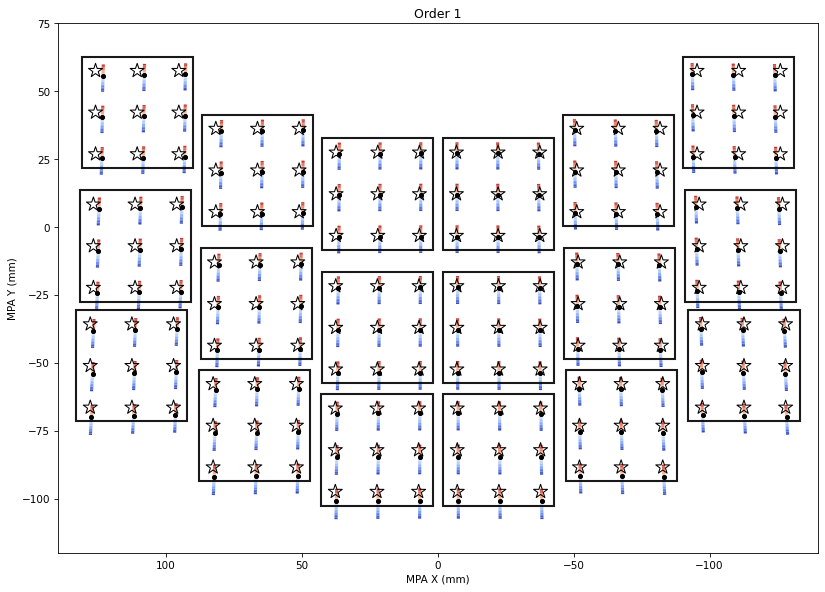

In [5]:
# Generate quicklook plot for order 1
fig1, ax1 = quick_look_jax_single('1', model, traces_jax)

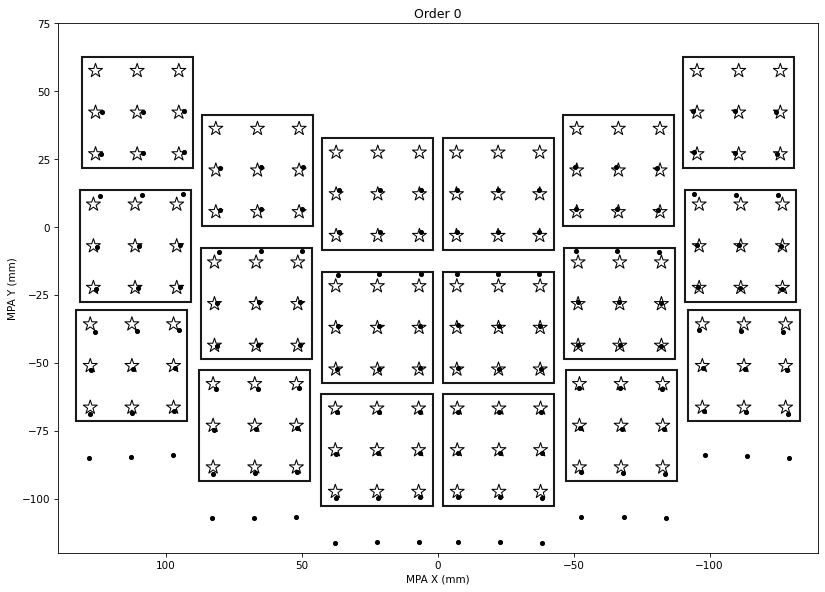

In [6]:
# Generate quicklook plot for order 0
fig2, ax2 = quick_look_jax_single('0', model, traces_jax)

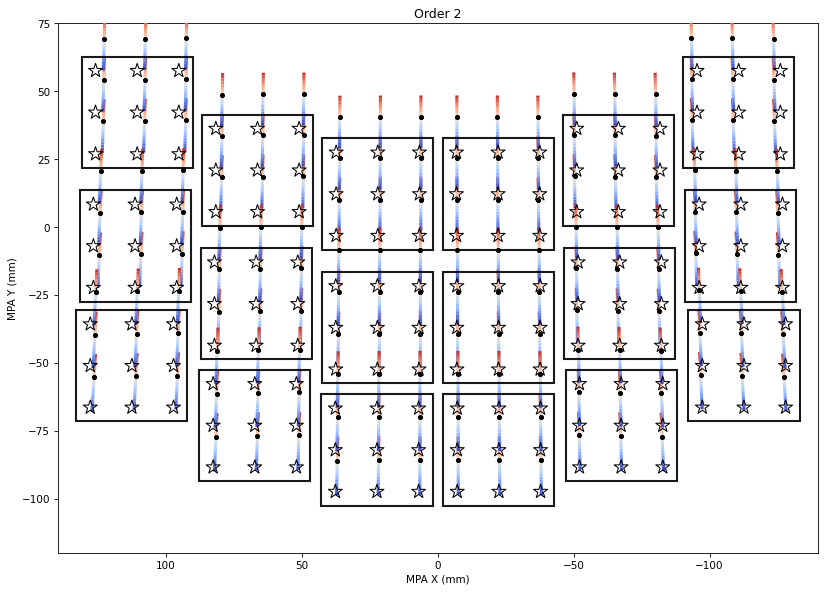

In [7]:
# Generate quicklook plot for order 2
fig3, ax3 = quick_look_jax_single('2', model, traces_jax)